# RESTOPS · Explain staffing, waste and promotion exceptions

In [1]:
from pathlib import Path
import json
import os
import sys

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".cache/matplotlib"))
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
from src.common import read, TABLEAU, REPORTS
from src.reporting import style
style()
pd.set_option("display.max_columns", 12)


**Business question:** Which operational interventions deserve a pilot?

Combine financial cost drivers with demand timing, peer waste rates, promotion contribution and customer-service guardrails.

In [2]:
stores = read("latest_store_opportunities", TABLEAU)
stores.sort_values("operating_margin_pct")[["restaurant_name", "operating_margin_pct", "labour_cost_pct", "waste_pct", "satisfaction_score"]].head(6)

,restaurant_name,operating_margin_pct,labour_cost_pct,waste_pct,satisfaction_score
5,Wollongong,0.018324,0.461708,0.077426,3.956403
14,Gold Coast,0.095632,0.390443,0.078158,3.872017
16,Toowoomba,0.095917,0.398852,0.048653,4.303896
11,Ballarat,0.105981,0.395654,0.049348,4.254190
9,Geelong,0.118826,0.380920,0.051510,4.255981
3,Newcastle,0.121285,0.379718,0.050562,4.227848


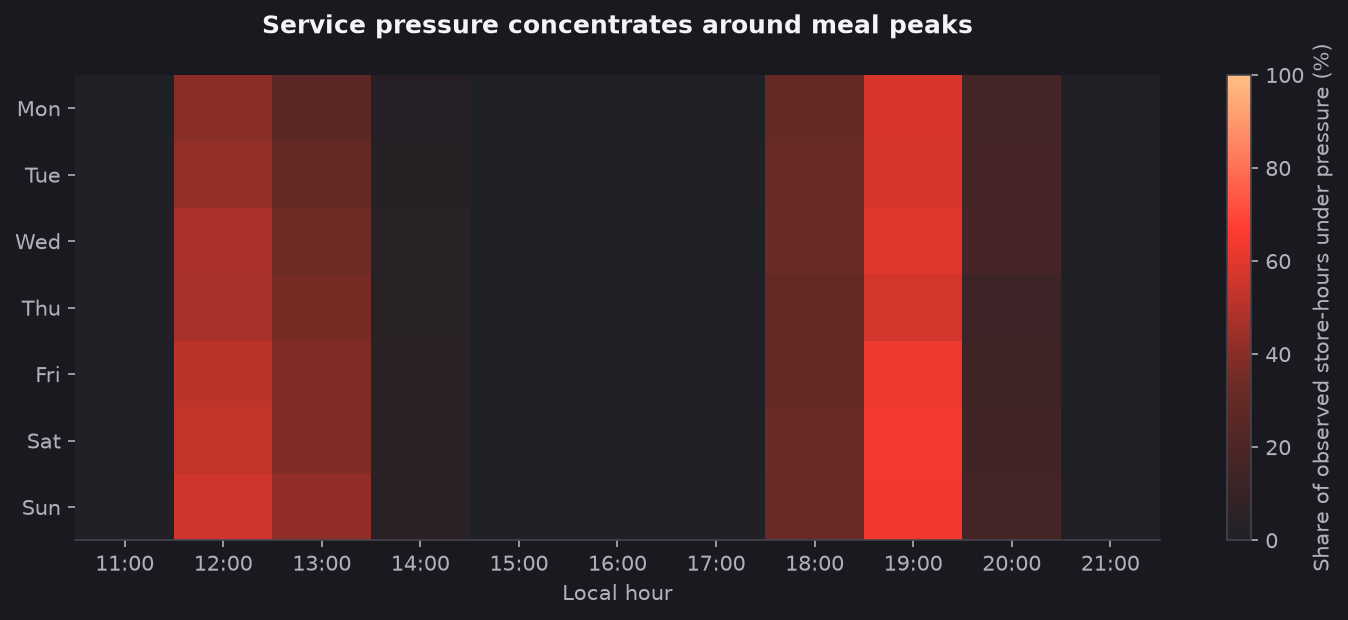

In [3]:
display(Image(filename=str(REPORTS / "figures/staffing_heatmap.png")))

In [4]:
patterns = read("staffing_patterns", TABLEAU)
patterns.sort_values("pressure_share", ascending=False).head(8)

,restaurant_id,weekday,hour,transactions,capacity,pressure_hours,observations,spare_hours,pressure_share
1141,15,5,19,15.230769,5.552885,103,104,0,0.990385
1152,15,6,19,13.711538,5.500000,97,104,0,0.932692
448,6,5,19,12.548077,5.500000,96,104,1,0.923077
1130,15,4,19,13.961538,5.500000,95,104,0,0.913462
1134,15,5,12,12.163462,5.400000,94,104,0,0.903846
1140,15,5,18,12.115385,5.552885,93,104,0,0.894231
1145,15,6,12,10.759615,5.400000,86,104,0,0.826923
437,6,4,19,10.903846,5.500000,86,104,2,0.826923


In [5]:
stores.sort_values("estimated_waste_opportunity", ascending=False)[["restaurant_name", "waste_pct", "waste_peer_median", "estimated_waste_opportunity"]].head(5)

,restaurant_name,waste_pct,waste_peer_median,estimated_waste_opportunity
14,Gold Coast,0.078158,0.043215,3629.529609
5,Wollongong,0.077426,0.050562,2044.470561
10,Southbank,0.040266,0.030349,952.195908
1,Parramatta,0.039250,0.034329,525.229645
13,South Brisbane,0.046953,0.043215,362.787412


In [6]:
promos = read("promotion_effectiveness", TABLEAU)
promos.dropna(subset=["incremental_contribution"]).groupby("campaign_name")[["incremental_revenue", "incremental_contribution", "campaign_cost"]].sum()

,incremental_revenue,incremental_contribution,campaign_cost
campaign_name,,,
Local Lunch,59897.340122,-112983.981811,14280
Spring Social,-56839.955884,-210901.189330,17680
Winter Value,-171916.185538,-238284.490816,22100


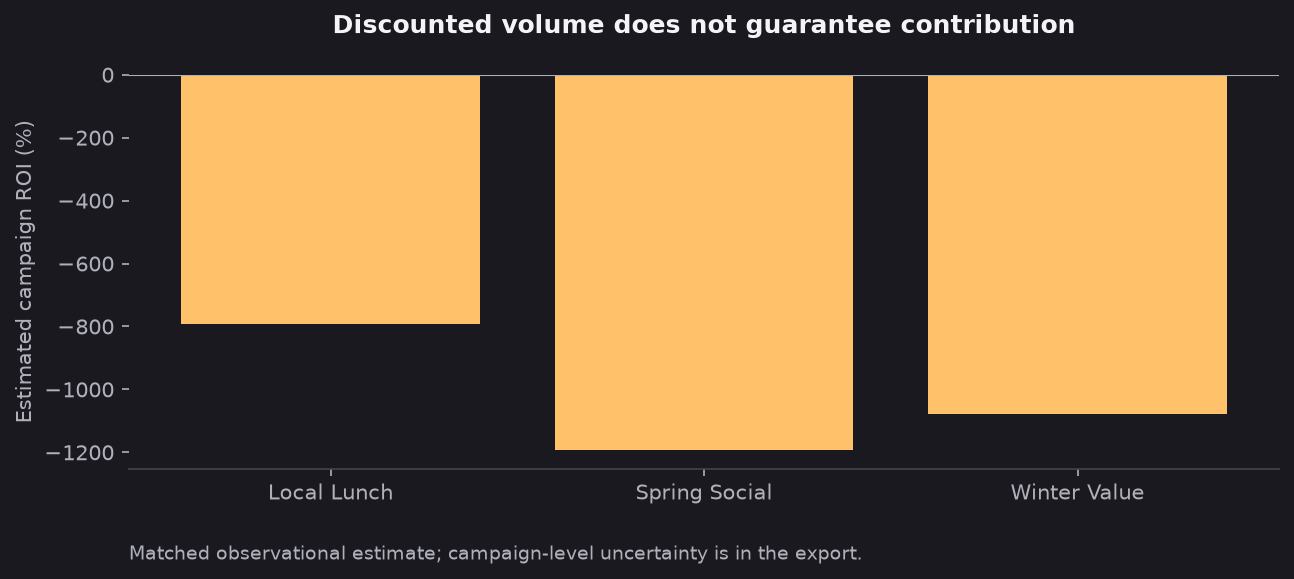

In [7]:
display(Image(filename=str(REPORTS / "figures/promotion_roi.png")))

In [8]:
pd.read_csv(REPORTS / "exports/kpi_correlations.csv")

,metric,operating_margin_pct,labour_cost_pct,waste_pct,satisfaction_score,sales_per_labour_hour,average_transaction_value,late_delivery_pct
0,operating_margin_pct,1.000000,-0.935110,-0.592660,0.348669,0.923859,0.533009,0.031692
1,labour_cost_pct,-0.935110,1.000000,0.715238,-0.417987,-0.970002,-0.328773,-0.091213
2,waste_pct,-0.592660,0.715238,1.000000,-0.720130,-0.740358,0.014512,0.092104
3,satisfaction_score,0.348669,-0.417987,-0.720130,1.000000,0.465668,-0.039184,-0.382463
4,sales_per_labour_hour,0.923859,-0.970002,-0.740358,0.465668,1.000000,0.346051,0.048711
5,average_transaction_value,0.533009,-0.328773,0.014512,-0.039184,0.346051,1.000000,-0.045518
6,late_delivery_pct,0.031692,-0.091213,0.092104,-0.382463,0.048711,-0.045518,1.000000


In [9]:
read("sales_anomalies", TABLEAU).head(6)

,restaurant_id,restaurant_name,business_date,revenue,prior_median,robust_z,is_public_holiday,promotion_id
0,1,Sydney Central,2025-06-09,1428.81,2574.200,-3.905791,1,NaN
1,1,Sydney Central,2025-08-25,3432.69,2176.015,5.531551,0,NaN
2,1,Sydney Central,2025-09-08,3153.87,2198.565,4.205000,0,NaN
3,1,Sydney Central,2025-05-13,1604.04,3010.305,-4.638041,0,NaN
4,1,Sydney Central,2025-09-23,4022.02,2576.300,4.804938,0,NaN
5,1,Sydney Central,2024-11-20,5059.00,3288.000,4.943774,0,NaN


In [10]:
summary = json.loads((REPORTS / "analysis_summary.json").read_text())
pd.Series(summary["staffing_association"])

controlled_correlation                                            -0.252549
ci_low                                                            -0.305662
ci_high                                                           -0.202083
store_days                                                            10399
method                    Ridge residualisation; approximate store-clust...
interpretation            Association, not a causal effect; survey respo...
dtype: object

**Decision:** Pilot roster timing and waste controls with service guardrails. KPI profitability correlations share accounting inputs, and promotion controls are observational. Neither demonstrates a causal intervention effect. Anomalies are investigation flags, not automatic deletions.